# ANÁLISIS EXPLORATORIO Y TRANSFORMACIÓN DE DATOS

### Librerias y Carga de datos


In [ ]:
# Instalación de librerías para EDA de datos médicos
!pip install pandas numpy matplotlib seaborn plotly
!pip install scikit-learn scipy
!pip install missingno # Para visualización de datos faltantes
!pip install sweetviz # Para reportes automáticos de EDA
!pip install pandas-profiling # Para perfilado automático de datos
!pip install imbalanced-learn # Para manejo de datos desbalanceados
!pip install openpyxl # Para leer archivos Excel si es necesario
!%pip install wordcloud # Para visualización de nubes de palabras

In [ ]:
# Importación de librerías esenciales para EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re
import unicodedata
from wordcloud import WordCloud
from plotly.subplots import make_subplots
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Para análisis estadístico
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Para visualización de datos faltantes
# import missingno as msno

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Configuración de warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_excel('../../data.xlsx')

print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

# Verificar valores nulos por columna
print(df.isnull().sum())


  - Filas: 3984
  - Columnas: 11
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            3
Datos Clínicos                     6
Hallazgos                          4
Opinión                            4
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     1
dtype: int64


In [6]:
df['Datos Clínicos'] = df['Datos Clínicos'].fillna('NR')
df['Técnica'] = df['Técnica'].fillna('NR')
df['Estudio Normal'] = df['Estudio Normal'].fillna(0)
# Eliminamos las filas con nulos en 'Hallazgos' o 'Opinión'
df = df.dropna(subset=['Hallazgos', 'Opinión'])
# Verificar valores nulos después de la limpieza
print(df.isnull().sum())

Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     0
Hallazgos                          0
Opinión                            0
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64


In [7]:
# Columnas de texto no estructurado a normalizar
text_columns = ['Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión']

for col in text_columns:
    # Convertir a string (por si hay valores numéricos o NaN)
    df[col] = df[col].astype(str)
    
    # Convertir a minúsculas
    df[col] = df[col].str.lower()
    
    # Eliminar espacios extra al inicio y final
    df[col] = df[col].str.strip()
    
    # Reemplazar múltiples espacios por un solo espacio
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
    
    # Normalizar puntuación: agregar espacio después de puntos, comas, etc.
    df[col] = df[col].str.replace(r'([.,:;!?])', r'\1 ', regex=True)
    
    # Eliminar espacios extra nuevamente
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

print("Normalización de texto no estructurado completada")

Normalización de texto no estructurado completada


In [8]:
# Verificar distribución de valores binarios
print("Distribución de Hallazgo Crítico:")
print(df['Hallazgo Crítico'].value_counts())

print("\nDistribución de Estudio Normal:")
print(df['Estudio Normal'].value_counts())

print("\nDistribución de Reporte estructurado:")
print(df['Reporte estructurado'].value_counts())

print("\nDistribución de Estudio Complementario Sugerido:")
print(df['Estudio Complementario Sugerido'].value_counts())

Distribución de Hallazgo Crítico:
Hallazgo Crítico
0    3082
1     895
Name: count, dtype: int64

Distribución de Estudio Normal:
Estudio Normal
0.0    2527
1.0    1450
Name: count, dtype: int64

Distribución de Reporte estructurado:
Reporte estructurado
0    3160
1     817
Name: count, dtype: int64

Distribución de Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    3837
1     140
Name: count, dtype: int64


In [9]:
for col in ['Modalidad', 'Estudio', 'Técnica', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Modalidad value counts:
Modalidad
CT    3977
Name: count, dtype: int64

Estudio value counts:
Estudio
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE                                          3328
TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE                                           382
 TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE                                          216
TOMOGRAFIA COMPUTADA DE CRANEO                                                   11
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE                                             8
TOMOGRAFIA COMPUTADA DE CRANEO                                                    5
TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE YCON CONTRASTE                              4
TOMOGRAFIA COMPUTADA DE CRANEO                                                    3
TOMOGRAFÍA COMPUTADA DE CRÁNEO CON CONTRASTE                                      3
Tomografía computada de cráneo simple.                                            2
TOMOGRAFIA COMPUTADA DE CRANEO Simple                    

In [10]:
def remove_accents(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_estudio(value):
    v = str(value).lower().strip()
    v = remove_accents(v)
    v = re.sub(r'\s+', ' ', v)
    v = v.replace('.', '')  # Elimina puntos finales
    # Angiotac (debe ir antes de "simple")
    if 'angiotac' in v:
        return 'tomografia computada de craneo simple con angiotac de arterias cerebrales'
    # Agrupar variantes de "simple"
    if re.search(r'tomografia computada de craneo simple', v) or \
        re.search(r'tomografia computada de craneo simpl', v) or \
        re.search(r'tomografia computada de craneo$', v) or \
        re.search(r'tomografia computada de crane$', v) or \
        re.search(r'tomografia computada de craneo simplev', v) or\
        re.search(r'tomografia axial computarizada de craneo simple dentro de limites normales', v) or\
        re.search(r'trauma craneoencefalico, cefalea y emesis', v) or\
        re.search(r'computada de craneo simple', v):
            return 'tomografia computada de craneo simple'
    # Agrupar variantes de "con contraste"
    if 'contraste' in v:
        return 'tomografia computada de craneo con contraste'
    # Agrupar columna cervical
    if 'columna cervical' in v:
        return 'tomografia computada de craneo y columna cervical simple'
    # TAC de recien nacidos
    if 'recien nacidos' in v:
        return 'tac de craneo simple recien nacidos'
    # Trauma, cefalea, emesis (caso único)
    if 'trauma' in v or 'cefalea' in v or 'emesis' in v:
        return v  # Mantener tal cual, es un caso único
    # Si nada coincide, devolver el valor normalizado
    return v

df['Estudio'] = df['Estudio'].apply(normalize_estudio)
print(df['Estudio'].value_counts())

Estudio
tomografia computada de craneo simple                                        3970
tomografia computada de craneo con contraste                                    3
tomografia computada de craneo y columna cervical simple                        2
tomografia computada de craneo simple con angiotac de arterias cerebrales       1
tac de craneo simple recien nacidos                                             1
Name: count, dtype: int64


In [11]:
df.to_excel('../../data_cleaned.xlsx', index=False)
print("Archivo normalizado guardado como 'data_cleaned.xlsx'")

# información final
print(f"\nDataFrame final:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")
print(f"\nValores nulos finales:")
print(df.isnull().sum())

Archivo normalizado guardado como 'data_cleaned.xlsx'

DataFrame final:
  - Filas: 3977
  - Columnas: 11

Valores nulos finales:
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     0
Hallazgos                          0
Opinión                            0
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64



Reporte estructurado:
Reporte estructurado
0    3160
1     817
Name: count, dtype: int64
Proporción de 1: 0.20543122957002766

Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    3837
1     140
Name: count, dtype: int64
Proporción de 1: 0.0352024138798089

Hallazgo Crítico:
Hallazgo Crítico
0    3082
1     895
Name: count, dtype: int64
Proporción de 1: 0.22504400301734975

Estudio Normal:
Estudio Normal
0.0    2527
1.0    1450
Name: count, dtype: int64
Proporción de 1: 0.3645964294694493


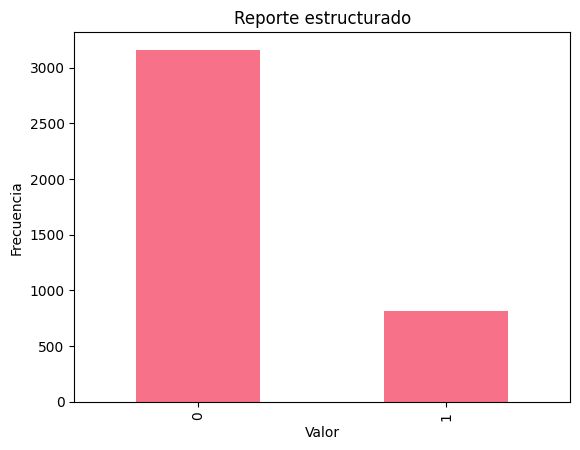

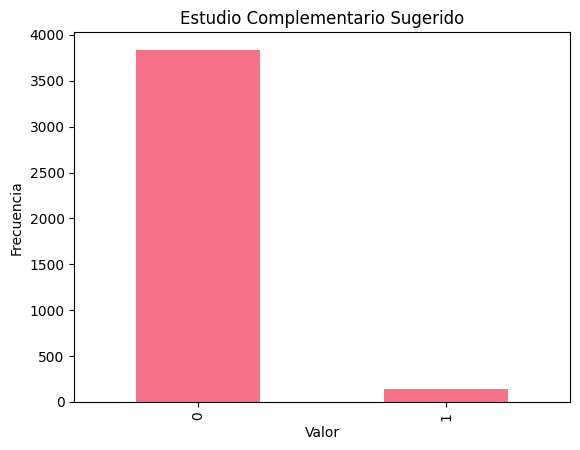

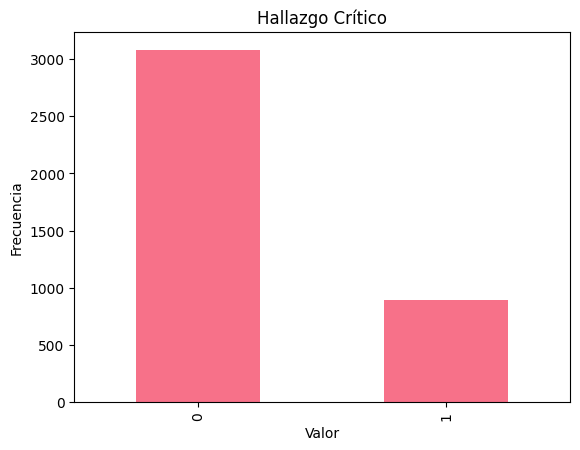

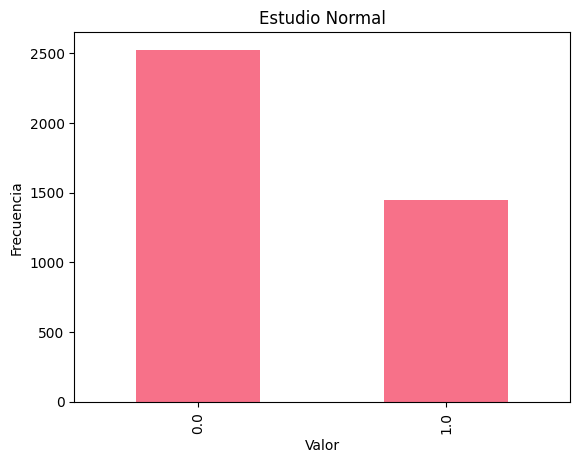

In [12]:
binary_cols = ['Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal']

for col in binary_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("Proporción de 1:", df[col].mean())

for col in binary_cols:
    df[col].value_counts().plot(kind='bar', title=col)
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.show()

### Distribución de variables binarias

- **Reporte estructurado:** Solo el 20.5% de los reportes están estructurados, lo que evidencia la necesidad de técnicas de PLN para analizar la mayoría de los informes.
- **Estudio Complementario Sugerido:** Apenas el 3.5% de los estudios sugieren un estudio adicional, mostrando un fuerte desbalance de clases.
- **Hallazgo Crítico:** El 22.5% de los estudios presentan hallazgos críticos, lo que resalta la importancia de su detección automática.
- **Estudio Normal:** El 36.5% de los estudios son normales, mientras que el resto presenta alguna alteración.

Estas proporciones permiten dimensionar el reto del análisis automático y la relevancia clínica de cada variable.

In [14]:
ct = pd.crosstab(df['Hallazgo Crítico'], df['Estudio Complementario Sugerido'])
print(ct)

Estudio Complementario Sugerido     0   1
Hallazgo Crítico                         
0                                2989  93
1                                 848  47


- La mayoría de los estudios con hallazgo crítico no sugieren un estudio complementario (848 vs 47).
- Solo el 5.2% (47/895) de los estudios con hallazgo crítico sugieren un estudio complementario.
Esto puede indicar que no todos los hallazgos críticos requieren seguimiento inmediato, o que la recomendación no siempre se documenta.

In [15]:
ct = pd.crosstab(df['Reporte estructurado'], df['Hallazgo Crítico'])
print(ct)

Hallazgo Crítico         0    1
Reporte estructurado           
0                     2536  624
1                      546  271


- Tanto en reportes estructurados como no estructurados, hay hallazgos críticos.
- La proporción de hallazgos críticos es ligeramente mayor en reportes estructurados (271/817 ≈ 33%) que en no estructurados (624/3160 ≈ 20%).
- Esto puede indiciar que los reportes estructurados pueden facilitar la identificación o documentación de hallazgos críticos.


In [52]:
# Muestra aleatoria de hallazgos y opiniones
print(df['Hallazgos'].sample(20, random_state=1))
print(df['Opinión'].sample(20, random_state=1))

all_text = ' '.join(df['Hallazgos'].dropna().astype(str).tolist()).lower()
words = re.findall(r'\b\w+\b', all_text)
counter = Counter(words)
print(counter.most_common(50))  # 50 palabras más frecuentes

vectorizer = CountVectorizer(ngram_range=(2,3), max_features=50)
X = vectorizer.fit_transform(df['Hallazgos'].dropna().astype(str).str.lower())
ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
ngram_freq = sorted(zip(ngrams, counts), key=lambda x: -x[1])
print(ngram_freq)

3047    surcos y circunvoluciones simétricos. sistema ...
1064    prominencia de los surcos en las convejidades ...
1889    prominencia surcos, circunvoluciones y espacio...
1759    parénquima cerebral de densidad homogénea, sin...
1674    hemorragia intraparenquimatosa: no. signos de ...
419     parénquima cerebral de densidad homogénea, sin...
950     surcos y circunvoluciones simétricos. sistema ...
788     surcos y circunvoluciones simétricos prominent...
861     surcos y circunvoluciones simétricos. sistema ...
1539    colecciones extra-axiales subdurales crónicas ...
2565    la hipodensidad la sustancia blanca periventri...
494     surcos y circunvoluciones simétricos y promine...
3269    hemorragia intraparenquimatosa: no. signos de ...
2442    surcos y espacio subaracnoideo prominente por ...
3029    surcos y espacios subaracnoideos prominentes p...
3593    signos de sangrado. hematoma subdural: si, fro...
689     prominencia de los surcos en las convejidades ...
1406    surcos

TOP 5 PALABRAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)
normal               5552
media                4101
ventricular          3751
línea                3681
sistema              3668

TOP 20 N-GRAMAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)
línea media                         3673
sistema ventricular                 3652
senos paranasales                   2823
hemorragia subaracnoidea            2371
fosa posterior                      2246
sustancia blanca                    2107
adecuada neumatización              1520
iv ventrículo                       1485
media central                       1485
línea media central                 1481
ventrículo central                  1472
iv ventrículo central               1470
parénquima cerebral                 1457
aspecto normal                      1443
neumatización mastoides             1438
diferenciación sustancia            1434
adecuada neumatización mastoides    1432
adecuada diferenciación             1391
ventanas ó

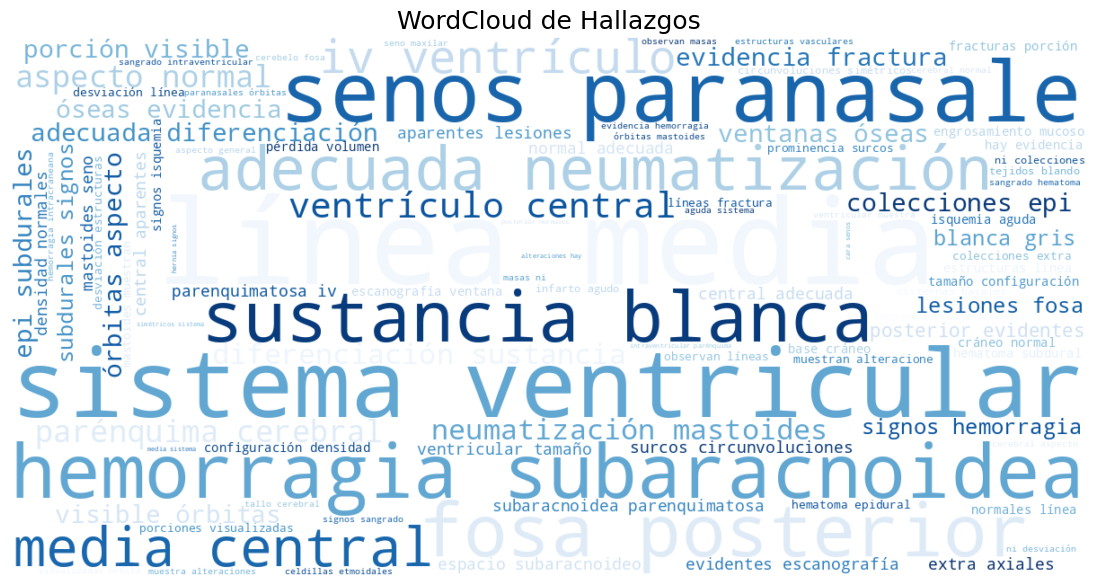

TOP 5 PALABRAS MÁS FRECUENTES EN OPINIONES (sin conectores)
cerebral             1587
estudio              1411
evidencia            1229
signos               1176
cambios              1006

TOP 20 N-GRAMAS MÁS FRECUENTES EN OPINIONES (sin conectores)
estudio evidencia                   709
pérdida volumen                     566
evidencia lesiones                  446
ocupantes espacio                   440
lesiones ocupantes                  402
lesiones ocupantes espacio          398
escanografia cerebral               384
leucoencefalopatía microangiopática 381
extra axiales                       355
ni signos                           355
hemorragia subaracnoidea            347
colecciones intra                   346
intra extra                         344
intra extra axiales                 344
colecciones intra extra             340
signos lesion                       337
ni signos lesion                    335
lesion expansiva                    334
signos lesion expansiva     

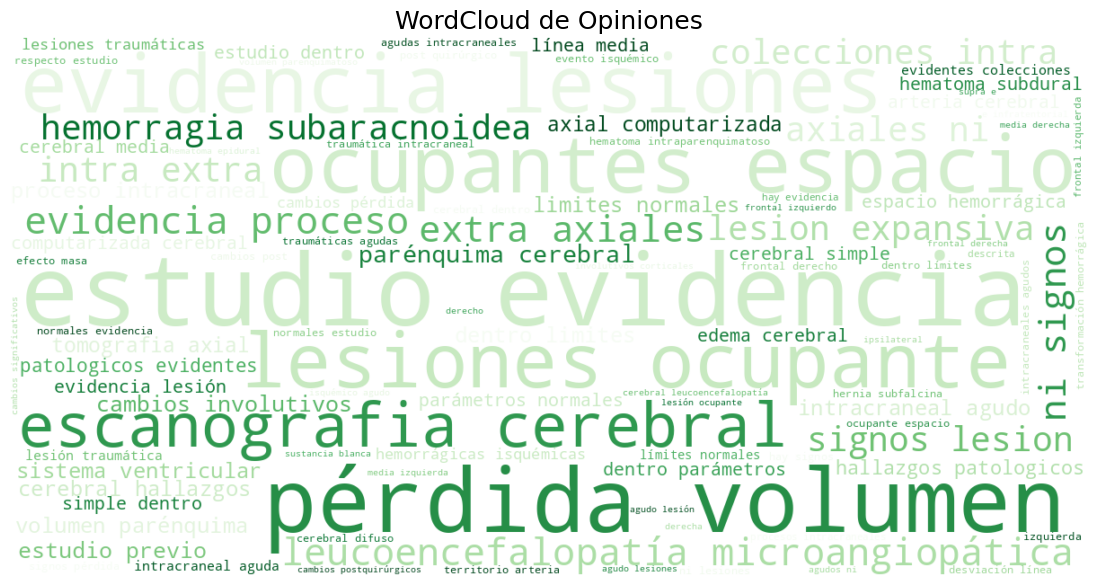

In [70]:
stopwords_es = [
    'de','la','y','el','en','del','con','se','las','los','por','para','al','lo','un','una','es','su','sus','que','a','o','sin','no'
]

# HALLAZGOS
all_text_h = ' '.join(df['Hallazgos'].dropna().astype(str).tolist()).lower()
words_h = re.findall(r'\b\w+\b', all_text_h)
words_h_filtradas = [w for w in words_h if w not in stopwords_es]
counter_h = Counter(words_h_filtradas)
print("TOP 5 PALABRAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)")
for palabra, freq in counter_h.most_common(5):
    print(f"{palabra:<20} {freq}")

vectorizer_h = CountVectorizer(ngram_range=(2,3), max_features=20, stop_words=stopwords_es)
X_h = vectorizer_h.fit_transform(df['Hallazgos'].dropna().astype(str).str.lower())
ngrams_h = vectorizer_h.get_feature_names_out()
counts_h = X_h.sum(axis=0).A1
ngram_freq_h = sorted(zip(ngrams_h, counts_h), key=lambda x: -x[1])
print("\nTOP 20 N-GRAMAS MÁS FRECUENTES EN HALLAZGOS (sin conectores)")
for ngrama, freq in ngram_freq_h:
    print(f"{ngrama:<35} {freq}")

corpus_hallazgos = ' '.join(words_h_filtradas)
wc_hallazgos = WordCloud(
    width=1200, height=600, background_color='white',
    stopwords=stopwords_es, colormap='Blues', max_words=100
).generate(corpus_hallazgos)
plt.figure(figsize=(14, 7))
plt.imshow(wc_hallazgos, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud de Hallazgos', fontsize=18)
plt.show()

# OPINIONES
all_text_o = ' '.join(df['Opinión'].dropna().astype(str).tolist()).lower()
words_o = re.findall(r'\b\w+\b', all_text_o)
words_o_filtradas = [w for w in words_o if w not in stopwords_es]
counter_o = Counter(words_o_filtradas)
print("TOP 5 PALABRAS MÁS FRECUENTES EN OPINIONES (sin conectores)")
for palabra, freq in counter_o.most_common(5):
    print(f"{palabra:<20} {freq}")

vectorizer_o = CountVectorizer(ngram_range=(2,3), max_features=20, stop_words=stopwords_es)
X_o = vectorizer_o.fit_transform(df['Opinión'].dropna().astype(str).str.lower())
ngrams_o = vectorizer_o.get_feature_names_out()
counts_o = X_o.sum(axis=0).A1
ngram_freq_o = sorted(zip(ngrams_o, counts_o), key=lambda x: -x[1])
print("\nTOP 20 N-GRAMAS MÁS FRECUENTES EN OPINIONES (sin conectores)")
for ngrama, freq in ngram_freq_o:
    print(f"{ngrama:<35} {freq}")

corpus_opiniones = ' '.join(words_o_filtradas)
wc_opiniones = WordCloud(
    width=1200, height=600, background_color='white',
    stopwords=stopwords_es, colormap='Greens', max_words=100
).generate(corpus_opiniones)
plt.figure(figsize=(14, 7))
plt.imshow(wc_opiniones, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud de Opiniones', fontsize=18)
plt.show()

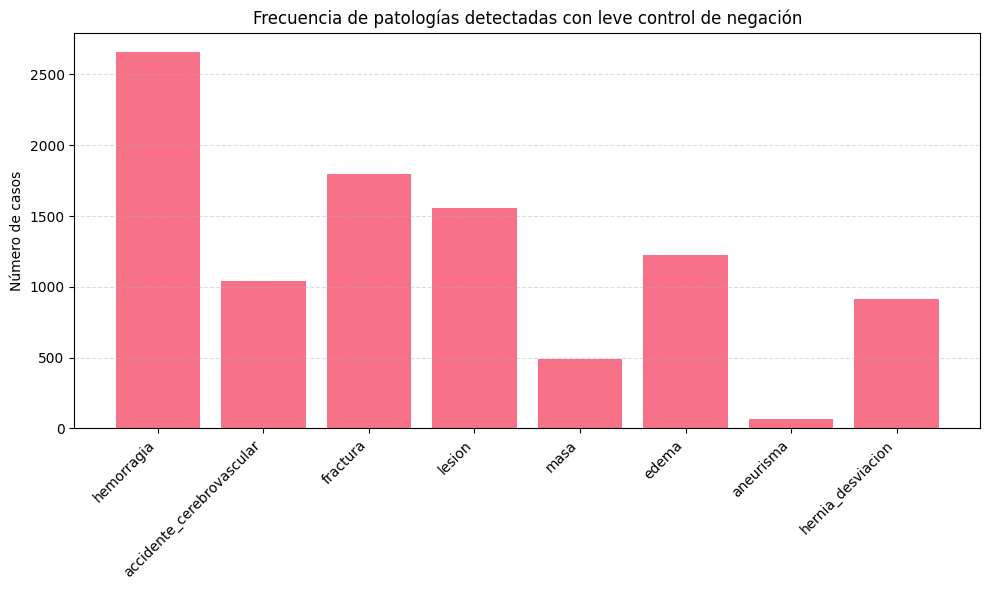

{'hemorragia': 2661, 'accidente_cerebrovascular': 1038, 'fractura': 1800, 'lesion': 1559, 'masa': 487, 'edema': 1228, 'aneurisma': 66, 'hernia_desviacion': 912}


In [80]:
# 1. Diccionario clínico: patologías / sinónimos
PATOLOGIAS = {
    "hemorragia": [
        r"hemorragia", r"hematoma", r"sangrado",
        r"coleccion hematic", r"hematocele"
    ],
    "accidente_cerebrovascular": [
        r"infarto", r"isquemia", r"ictus", r"acv",
        r"evento cerebrovascular", r"hipodensidad sugestiva de isquemia"
    ],
    "fractura": [
        r"fractura", r"linea de fractura", r"trazo de fractura"
    ],
    "lesion": [
        r"lesion", r"lesiones", r"area lesion", r"contusion"
    ],
    "masa": [
        r"masa", r"lesion ocupante de espacio", r"loe", r"tumor",
        r"neoplasia", r"lesion nodular"
    ],
    "edema": [
        r"edema", r"hipodensidad difusa compatible con edema"
    ],
    "aneurisma": [
        r"aneurisma", r"dilatacion aneurismatica"
    ],
    "hernia_desviacion": [
        r"hernia", r"herniacion",
        r"desviaci[oó]n de la l[ií]nea media", r"desviacion de la linea media"
    ]
}
# 2. Negaciones robustas
NEGACIONES = [
    r"no se observa", r"no se evidencia", r"no hay",
    r"sin evidencia de", r"sin signos de", r"ausencia de",
    r"negativa para", r"niega", r"descarta"
]

# 3. Función para detección
def detectar_patologia(texto, patrones_pos, patrones_neg, ventana=60):
    if not isinstance(texto, str):
        return False

    texto = texto.lower()

    # Buscar patrones positivos
    for pos in patrones_pos:
        for match in re.finditer(pos, texto):
            start = match.start()

            # Revisar si hay negaciones antes dentro de una ventana contextual
            ventana_inicio = max(0, start - ventana)
            contexto = texto[ventana_inicio:start]

            if not any(re.search(neg, contexto) for neg in patrones_neg):
                return True

    return False

# 4. Aplicación y conteo
resultados = {}

for nombre, patrones in PATOLOGIAS.items():
    count = df["Hallazgos"].apply(
        lambda x: detectar_patologia(x, patrones, NEGACIONES)
    ).sum()

    resultados[nombre] = count

# 5. Visualización 
plt.figure(figsize=(10, 6))
plt.bar(resultados.keys(), resultados.values())
plt.ylabel("Número de casos")
plt.title("Frecuencia de patologías detectadas con leve control de negación")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print(resultados)

## Selección de categorías diagnósticas predominantes

Tras el análisis exploratorio de frecuencias y relevancia clínica, **consideramos como opción predominante** las siguientes categorías para el modelo de clasificación automática:

- hemorragia /  hematoma cerebral
- accidente cerebrovascular
- fractura
- masa

Esto por su frecuencia, relevancia clínica y claridad en los reportes. Se crearán variables binarias para cada una, que servirán como etiquetas principales en el entrenamiento y validación del modelo.